<a href="https://colab.research.google.com/github/sokrypton/7.571/blob/main/L7/pearson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from scipy.stats import pearsonr as statsr
import matplotlib.pylab as plt

In [ ]:
def calc_pearson_r(x_values, y_values):
    assert x_values.shape[0] == y_values.shape[0]
    x_bar = x_values.mean()
    y_bar = y_values.mean()
    num_samples = x_values.shape[0]

    x_std = x_values.std()
    y_std = y_values.std()

    total_deviation = 0
    for position, x_value in enumerate(x_values):
        y_value = y_values[position]
        total_deviation+=(x_bar - x_value)*(y_bar - y_value)

    return round(total_deviation/((num_samples)*x_std*y_std),3)

**Positive slopes relating x and y (no scatter, perfect correlations)**

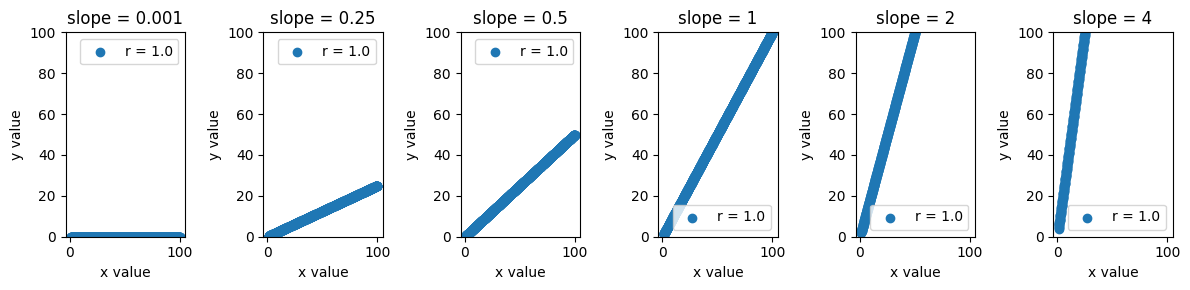

In [ ]:
slopes = [0.001, 0.25, 0.5, 1, 2, 4] # various linear factors, no noise
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(12,3))
for ax_number, slope in enumerate(slopes):
    x_values = np.arange(1,100,.1)
    y_values = []
    for x_value in x_values:
        y_values.append(x_value*slope)
    y_values = np.array(y_values)
    axes[ax_number].scatter(x_values, y_values, label='r = ' + str((calc_pearson_r(x_values, y_values))))
    axes[ax_number].legend()
    axes[ax_number].set_title('slope = ' + str(slope))
    axes[ax_number].set_ylim(0, 100)
    axes[ax_number].set_xlabel('x value')
    axes[ax_number].set_ylabel('y value')
plt.tight_layout()


**Negative slopes relating x and y (no scatter, perfect correlations)**
* note that slope of 0 has ill-defined pearson correlation because the standard deviation of the y-values is 0
* also note that I've added a fixed offset to each y-value (100), which doesn't affect the correlation

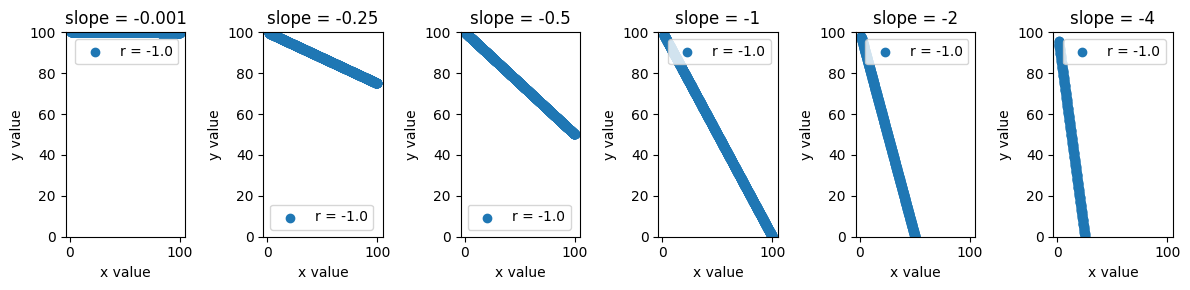

In [ ]:
slopes = [-0.001, -0.25, -0.5, -1, -2, -4] # various linear factors, no noise
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(12,3))
for ax_number, slope in enumerate(slopes):
    x_values = np.arange(1,100,.1)
    y_values = []
    for x_value in x_values:
        y_values.append(x_value*slope+100)
    y_values = np.array(y_values)
    axes[ax_number].scatter(x_values, y_values, label='r = ' + str((calc_pearson_r(x_values, y_values))))
    axes[ax_number].legend()
    axes[ax_number].set_title('slope = ' + str(slope))
    axes[ax_number].set_ylim(0, 100)
    axes[ax_number].set_xlabel('x value')
    axes[ax_number].set_ylabel('y value')
plt.tight_layout()


**Data without a LINEAR correlation**
    * note that data may still be perfectly correlated but requires a non-linear transform (log, squared, etc.)

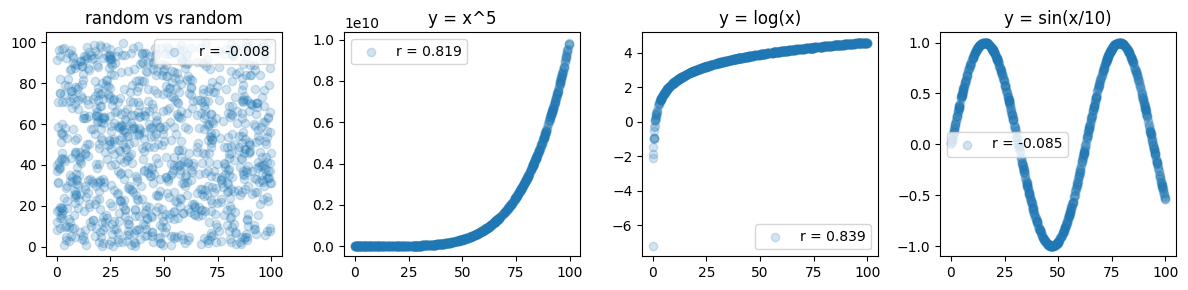

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12,3))
#uncorrelated
x_values = np.array([np.random.random()*100 for i in range(0,1000)])
y_values = np.array([np.random.random()*100 for i in range(0,1000)])
axes[0].scatter(x_values, y_values, label='r = ' + str((calc_pearson_r(x_values, y_values))), alpha=0.2)
axes[0].legend()
axes[0].set_title('random vs random')

#non-linearlly related (y = x^5)
x_values = np.array([np.random.random()*100 for i in range(0,1000)])
y_values = x_values**5
axes[1].scatter(x_values, y_values, label='r = ' + str((calc_pearson_r(x_values, y_values))), alpha=0.2)
axes[1].legend()
axes[1].set_title('y = x^5')

#non-linearlly related (y = log(x))
x_values = np.array([np.random.random()*100 for i in range(0,1000)])
y_values = np.log(x_values)
axes[2].scatter(x_values, y_values, label='r = ' + str((calc_pearson_r(x_values, y_values))), alpha=0.2)
axes[2].legend()
axes[2].set_title('y = log(x)')

#non-linearlly related (y = sin(x))
x_values = np.array([np.random.random()*100 for i in range(0,1000)])
y_values = np.sin(x_values/10)
axes[3].scatter(x_values, y_values, label='r = ' + str((calc_pearson_r(x_values, y_values))), alpha=0.2)
axes[3].legend()
axes[3].set_title('y = sin(x/10)')
plt.tight_layout()

**Data with a linear correlation and some noise**

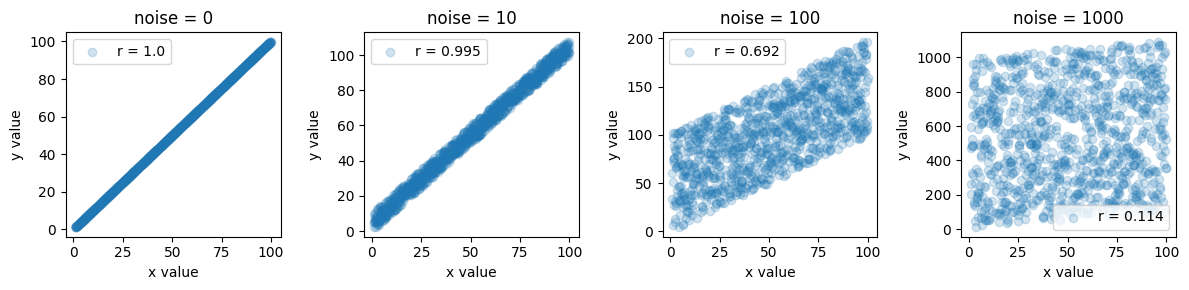

In [ ]:
noises = [0, 10, 100, 1000] # various linear factors, no noise
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12,3))
for ax_number, noise in enumerate(noises):
    x_values = np.arange(1,100,.1)
    y_values = []
    for x_value in x_values:
        y_values.append(x_value+np.random.random()*noise)
    y_values = np.array(y_values)
    axes[ax_number].scatter(x_values, y_values, label='r = ' + str((calc_pearson_r(x_values, y_values))), alpha=0.2)
    axes[ax_number].legend()
    axes[ax_number].set_title('noise = ' + str(noise))
    #axes[ax_number].set_ylim(0, 100)
    axes[ax_number].set_xlabel('x value')
    axes[ax_number].set_ylabel('y value')
plt.tight_layout()